# Golf Swing Band Classification — Training Notebook

This notebook is aligned with the current pipeline outputs:
- Sequences: `processed_videos/sequences/*.npz` containing `X_joint (T,33,13)`, `X_global (T,3)`, `y`
- Interpolation masks: `processed_videos/interp_masks/*.npz`
- Processed metadata: `processed_videos/metadata/processed_metadata.csv`
- Splits: `processed_videos/splits/dataset_splits.json`
- Scalers: `processed_videos/features/feature_scaler.json`

It loads all sample-level metadata and keeps a direct mapping to `video_id`, `env`, `band`, and file paths.

In [82]:
# --- Imports ---
import json
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import config

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [83]:
# --- Resolve pipeline artifacts (direct mapping to current pipeline) ---
OUTPUT_ROOT = Path(config.OUTPUT_ROOT)
SEQ_DIR = OUTPUT_ROOT / config.FINAL_SEQUENCE_SUBDIR          # processed_videos/sequences
MASK_DIR = OUTPUT_ROOT / config.INTERPOLATION_MASK_SUBDIR     # processed_videos/interp_masks
META_DIR = OUTPUT_ROOT / config.FINAL_METADATA_SUBDIR         # processed_videos/metadata
SPLIT_DIR = OUTPUT_ROOT / config.FINAL_SPLIT_SUBDIR           # processed_videos/splits
FEAT_DIR = OUTPUT_ROOT / config.FINAL_FEATURE_SUBDIR          # processed_videos/features

PROCESSED_METADATA_CSV = META_DIR / "processed_metadata.csv"
SPLITS_JSON = SPLIT_DIR / "dataset_splits.json"
SCALER_JSON = FEAT_DIR / config.SCALER_FILENAME

print("SEQ_DIR:", SEQ_DIR)
print("MASK_DIR:", MASK_DIR)
print("PROCESSED_METADATA_CSV:", PROCESSED_METADATA_CSV)
print("SPLITS_JSON:", SPLITS_JSON)
print("SCALER_JSON:", SCALER_JSON)

for p in [SEQ_DIR, MASK_DIR, META_DIR, SPLIT_DIR, FEAT_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing pipeline output folder: {p}")
for p in [PROCESSED_METADATA_CSV, SPLITS_JSON, SCALER_JSON]:
    if not p.exists():
        raise FileNotFoundError(f"Missing pipeline artifact: {p}")

SEQ_DIR: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\sequences
MASK_DIR: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\interp_masks
PROCESSED_METADATA_CSV: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\metadata\processed_metadata.csv
SPLITS_JSON: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\splits\dataset_splits.json
SCALER_JSON: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\features\feature_scaler.json


In [84]:
# --- Load processed sample metadata + split mapping ---
processed_df = pd.read_csv(PROCESSED_METADATA_CSV)
with open(SPLITS_JSON, "r", encoding="utf-8") as f:
    split_map = json.load(f)

# The pipeline assigns splits into sample_records, but splits.json is stored per base video_id.
# We'll reconstruct each sample's split:
def resolve_split(row) -> str:
    if bool(row.get("augmented", False)):
        return "train"
    vid = str(row["video_id"])
    return split_map.get(vid, "train")

processed_df["split"] = processed_df.apply(resolve_split, axis=1)

print("Processed samples:", len(processed_df))
print(processed_df["split"].value_counts())
print("Columns:", list(processed_df.columns))

Processed samples: 332
split
train    272
val       30
test      30
Name: count, dtype: int64
Columns: ['video_id', 'augmented', 'env', 'band', 'band_id', 'sequence_path', 'interpolation_mask_path', 'low_quality', 'valid_ratio', 'mean_visibility', 'longest_dropout', 'interpolation_ratio', 'split']


In [85]:
# --- Load scalers (for inspection / potential model-side normalization) ---
with open(SCALER_JSON, "r", encoding="utf-8") as f:
    scaler = json.load(f)

joint_mean = np.asarray(scaler["joint_mean"], dtype=np.float32)
joint_std  = np.asarray(scaler["joint_std"], dtype=np.float32)
global_mean = np.asarray(scaler["global_mean"], dtype=np.float32)
global_std  = np.asarray(scaler["global_std"], dtype=np.float32)

print("Joint mean/std:", joint_mean.shape, joint_std.shape)
print("Global mean/std:", global_mean.shape, global_std.shape)

assert joint_mean.shape == (config.POSE_JOINT_FEATURE_DIM,)
assert global_mean.shape == (config.POSE_GLOBAL_FEATURE_DIM,)

Joint mean/std: (13,) (13,)
Global mean/std: (3,) (3,)


In [86]:
# --- Dataset: loads X_joint, X_global, y + keeps direct mapping to metadata ---
# Ordinal regression: map band_id -> rank in [0..4]
BAND_ID_TO_RANK = {
    0: 0,  # Band 1-2
    1: 1,  # Band 2-4
    2: 2,  # Band 4-6
    3: 3,  # Band 6-8
    4: 4,  # Band 8-10
}

class SwingBandDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split: str):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.split = split

        if len(self.df) == 0:
            raise ValueError(f"No samples found for split='{split}'. Check processed_metadata.csv and splits.json.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # sequence_path stored relative to config.BASE_DIR by the pipeline
        seq_path = Path(config.BASE_DIR) / Path(str(row["sequence_path"]))
        if not seq_path.exists():
            raise FileNotFoundError(f"Sequence not found: {seq_path}")

        npz = np.load(seq_path, allow_pickle=True)
        X_joint = npz["X_joint"].astype(np.float32)   # (T,33,13)
        X_global = npz["X_global"].astype(np.float32) # (T,3)
        band_id = int(npz["y"].astype(np.int64))      # Original band_id (0..4)

        # Convert band_id to ordinal rank
        y_rank = int(BAND_ID_TO_RANK[band_id])

        # Define mask_path before using it in meta
        mask_path = Path(config.BASE_DIR) / Path(str(row["interpolation_mask_path"]))
        interp_mask = None
        if mask_path.exists():
            m = np.load(mask_path, allow_pickle=True)
            interp_mask = m["interpolation_mask"].astype(bool)  # (T,33)

        # Convert to torch tensors
        X_joint_t = torch.from_numpy(X_joint)
        X_global_t = torch.from_numpy(X_global)
        y_t = torch.tensor(y_rank, dtype=torch.long)  # Ordinal rank as long tensor

        meta = {
            "video_id": str(row["video_id"]),
            "env": str(row["env"]),
            "band_str": str(row["band"]),
            "band_id": band_id,  # Keep original band_id for evaluation/debug
            "low_quality": bool(row.get("low_quality", False)),
            "interpolation_ratio": float(row.get("interpolation_ratio", 0.0)),
            "sequence_path": str(seq_path),
            "mask_path": str(mask_path),
        }

        return X_joint_t, X_global_t, y_t, meta, interp_mask


def collate_fn(batch):
    # All sequences are expected to be fixed-length (T = config.N_FRAMES) by the pipeline.
    Xj, Xg, y, meta, masks = zip(*batch)
    Xj = torch.stack(Xj, dim=0)  # (B,T,33,13)
    Xg = torch.stack(Xg, dim=0)  # (B,T,3)
    y = torch.stack(y, dim=0)    # (B,) ordinal rank as long tensor

    # masks are optional; keep as list for debugging
    return Xj, Xg, y, list(meta), list(masks)


train_ds = SwingBandDataset(processed_df, "train")
val_ds   = SwingBandDataset(processed_df, "val")
test_ds  = SwingBandDataset(processed_df, "test")

BATCH_SIZE = 16
from torch.utils.data import WeightedRandomSampler
import numpy as np

# Build sampler from TRAIN labels to balance classes (based on original band_id)
train_labels = train_ds.df["band_id"].astype(int).values
num_classes = len(config.BANDS)

class_counts = np.bincount(train_labels, minlength=num_classes)
sample_weights = 1.0 / class_counts[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,          # <-- use sampler for class balancing
    shuffle=False,            # <-- must be False when using sampler
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))
print("Train class counts:", {config.ID_TO_BAND[i]: int(class_counts[i]) for i in range(num_classes)})

Train/Val/Test: 272 30 30
Train class counts: {'1_2': 51, '2_4': 41, '4_6': 66, '6_8': 71, '8_10': 43}


In [87]:
# --- Model: Joint + Global fusion with temporal encoder (CORAL ordinal regression) ---

class CoralLayer(nn.Module):
    """
    CORAL: Consistent Rank Logits layer.
    Uses a single shared linear mapping followed by learnable biases per threshold.
    This enforces monotonicity: logits[t] = s + bias[t], where s is the shared score.
    """
    def __init__(self, in_features, num_thresholds=4):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)  # Shared weight, no bias
        self.bias = nn.Parameter(torch.zeros(num_thresholds))  # Learnable thresholds
    
    def forward(self, x):
        s = self.fc(x)  # (B, 1)
        return s + self.bias.view(1, -1)  # (B, 4) — broadcasts bias


class BandOrdinalModel(nn.Module):
    def __init__(self, hidden_dim=128, lstm_layers=1, dropout=0.35, num_ordinal_logits=4, num_classes=5):
        super().__init__()
        joint_in = 33 * config.POSE_JOINT_FEATURE_DIM

        self.joint_fc = nn.Sequential(
            nn.Linear(joint_in, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        # global: pool across time -> (B,3) then map -> (B,H)
        self.global_mlp = nn.Sequential(
            nn.Linear(config.POSE_GLOBAL_FEATURE_DIM, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.0,          # keep 0 when 1 layer (more stable)
            bidirectional=True,
        )

        # attention over time (B,T,2H) -> weights (B,T,1)
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Dropout(dropout),  # regularize attention
            nn.Linear(hidden_dim, 1),
        )

        # gate to prevent global features from dominating
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        # Fused feature dimension: bidirectional LSTM (2H) + gated global (H)
        fused_dim = hidden_dim * 2 + hidden_dim

        # Preprocessing for ordinal/classification heads
        self.fused_fc = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        # CORAL ordinal head: shared weight + learnable biases
        self.coral = CoralLayer(hidden_dim, num_thresholds=num_ordinal_logits)

        # Auxiliary classification head (multitask learning)
        self.cls_head = nn.Linear(hidden_dim, num_classes)

    def forward(self, X_joint, X_global):
        B, T, J, D = X_joint.shape

        xj = X_joint.reshape(B, T, J * D)
        xj = self.joint_fc(xj)             # (B,T,H)

        out, _ = self.lstm(xj)             # (B,T,2H)

        w = self.attn(out)                 # (B,T,1)
        w = torch.softmax(w, dim=1)
        seq = (out * w).sum(dim=1)         # (B,2H)

        g = X_global.mean(dim=1)           # (B,3)
        g = self.global_mlp(g)             # (B,H)
        g = g * self.gate(g)               # gated global

        fused = torch.cat([seq, g], dim=-1)  # (B, 3H)
        h = self.fused_fc(fused)             # (B, H)

        logits_ord = self.coral(h)           # (B, 4)
        logits_cls = self.cls_head(h)        # (B, 5)

        return logits_ord, logits_cls


model = BandOrdinalModel().to(DEVICE)
print(model)

BandOrdinalModel(
  (joint_fc): Sequential(
    (0): Linear(in_features=429, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.35, inplace=False)
  )
  (global_mlp): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.35, inplace=False)
  )
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attn): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
  (gate): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (fused_fc): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=

In [88]:
# --- Train / Eval loops (CORAL Ordinal Regression + Multitask) ---
import torch
import torch.nn as nn
import torch.optim as optim

# Helper: convert rank to cumulative binary target
def rank_to_ordinal_target(y_rank, num_thresholds=4):
    """
    Convert rank labels [0..4] to cumulative binary targets [B, 4].
    y_rank: (B,) long tensor with values in {0,1,2,3,4}
    Returns: (B, 4) float tensor where y_ord[i,t] = 1 if rank[i] > t else 0
    """
    B = y_rank.size(0)
    y_ord = torch.zeros(B, num_thresholds, dtype=torch.float32, device=y_rank.device)
    for t in range(num_thresholds):
        y_ord[:, t] = (y_rank > t).float()
    return y_ord


# Compute pos_weight from train_ds (true distribution, not sampler-biased)
def compute_pos_weight_ordinal(train_ds, num_thresholds=4):
    """
    Compute pos_weight per threshold from true train labels.
    Uses train_ds.df directly to avoid sampler bias.
    pos_weight[t] = count(rank <= t) / max(count(rank > t), 1)
    """
    # Get band_id from train_ds and convert to rank (identity mapping in this case)
    all_ranks = train_ds.df["band_id"].astype(int).values
    
    pos_weight = []
    for t in range(num_thresholds):
        pos = (all_ranks > t).sum()
        neg = (all_ranks <= t).sum()
        weight = neg / max(pos, 1)
        pos_weight.append(weight)
    
    return torch.tensor(pos_weight, dtype=torch.float32)


pos_weight_ordinal = compute_pos_weight_ordinal(train_ds, num_thresholds=4).to(DEVICE)
print("Pos weights (per threshold):", pos_weight_ordinal)

# Loss functions
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight_ordinal)
ce_loss = nn.CrossEntropyLoss(label_smoothing=0.05)
ce_weight = 0.3  # Weight for auxiliary classification task

# AdamW + weight decay to prevent overfitting
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

# LR scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


def infer_rank_from_ordinal(logits_ord):
    """
    Convert ordinal logits to rank predictions using expected value.
    logits_ord: (B, 4)
    probs = sigmoid(logits_ord)
    expected = sum(probs)  in ~[0..4]
    pred_rank = round(expected) clamped to [0,4]
    """
    probs = torch.sigmoid(logits_ord)
    expected = probs.sum(dim=1)  # (B,) — expected rank
    pred_rank = torch.round(expected).long()  # (B,)
    pred_rank = torch.clamp(pred_rank, 0, 4)  # Safety clamp
    return pred_rank


def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    total = 0
    correct = 0
    total_mae = 0.0

    for Xj, Xg, y_rank, meta, masks in tqdm(loader, leave=False):
        Xj = Xj.to(DEVICE)
        Xg = Xg.to(DEVICE)
        y_rank = y_rank.to(DEVICE)

        # Convert rank to ordinal target
        y_ord = rank_to_ordinal_target(y_rank, num_thresholds=4)

        if train:
            optimizer.zero_grad()

        logits_ord, logits_cls = model(Xj, Xg)  # (B,4), (B,5)

        # Sanity checks
        assert logits_ord.shape == (y_rank.size(0), 4), f"Expected (B,4), got {logits_ord.shape}"
        assert logits_cls.shape == (y_rank.size(0), 5), f"Expected (B,5), got {logits_cls.shape}"
        assert y_rank.min() >= 0 and y_rank.max() <= 4, f"y_rank out of bounds: {y_rank.min()}-{y_rank.max()}"

        # Multitask loss: ordinal BCE + auxiliary classification CE
        loss_ord = bce_loss(logits_ord, y_ord)
        loss_cls = ce_loss(logits_cls, y_rank)
        loss = loss_ord + ce_weight * loss_cls

        if train:
            loss.backward()
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += float(loss.item()) * y_rank.size(0)
        total += y_rank.size(0)

        # Compute rank accuracy and MAE using ordinal predictions
        pred_rank = infer_rank_from_ordinal(logits_ord.detach())
        correct += int((pred_rank == y_rank).sum().item())
        total_mae += float((pred_rank - y_rank).abs().sum().item())

    val_loss = total_loss / max(total, 1)
    val_acc = correct / max(total, 1)
    val_mae = total_mae / max(total, 1)
    
    return val_loss, val_acc, val_mae


EPOCHS = 30
best_val = float("inf")
best_state = None
patience = 7
bad = 0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_mae": [], "val_mae": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_mae = run_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_mae         = run_epoch(model, val_loader,   train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} mae {train_mae:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} mae {val_mae:.3f} | lr {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step(val_loss)

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print("Best val loss:", best_val)

Pos weights (per threshold): tensor([0.2308, 0.5111, 1.3860, 5.3256])


Epoch 01 | train loss 1.1651 acc 0.268 mae 1.096 | val loss 1.1732 acc 0.267 mae 1.200 | lr 1.00e-03


Epoch 02 | train loss 0.9052 acc 0.379 mae 0.827 | val loss 0.9090 acc 0.300 mae 1.000 | lr 1.00e-03


Epoch 03 | train loss 0.7721 acc 0.371 mae 0.820 | val loss 1.0121 acc 0.167 mae 1.367 | lr 1.00e-03


Epoch 04 | train loss 0.6456 acc 0.482 mae 0.607 | val loss 0.9314 acc 0.333 mae 1.033 | lr 1.00e-03


...

Epoch 08 | train loss 0.4742 acc 0.548 mae 0.529 | val loss 1.1134 acc 0.233 mae 1.067 | lr 1.00e-03


Epoch 09 | train loss 0.4611 acc 0.566 mae 0.489 | val loss 0.9838 acc 0.233 mae 0.967 | lr 5.00e-04


Epoch 10 | train loss 0.4133 acc 0.555 mae 0.500 | val loss 1.0611 acc 0.300 mae 1.033 | lr 5.00e-04


Epoch 11 | train loss 0.4260 acc 0.592 mae 0.452 | val loss 1.0543 acc 0.267 mae 0.967 | lr 5.00e-04


Epoch 12 | train loss 0.4165 acc 0.562 mae 0.478 | val loss 1.0518 acc 0.300 mae 0.867 | lr 2.50e-04
Early stopping.
Best val loss: 0.7991140882174174


In [89]:
# --- Save trained model checkpoint ---
import datetime

# Create checkpoint directory
checkpoint_dir = OUTPUT_ROOT / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

# Generate timestamp for filename
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_path = checkpoint_dir / f"coral_ordinal_model_{timestamp}.pth"

# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'history': history,
    'best_val_loss': best_val,
    'epoch': len(history['train_loss']),
    'model_config': {
        'hidden_dim': 128,
        'lstm_layers': 1,
        'dropout': 0.35,
        'num_ordinal_logits': 4,
        'num_classes': 5
    }
}

torch.save(checkpoint, checkpoint_path)
print(f"✓ Model checkpoint saved to: {checkpoint_path}")
print(f"  - Best val loss: {best_val:.4f}")
print(f"  - Total epochs: {len(history['train_loss'])}")
print(f"  - Final train acc: {history['train_acc'][-1]:.3f}")
print(f"  - Final val acc: {history['val_acc'][-1]:.3f}")

# Also save a "latest" version for easy loading
latest_path = checkpoint_dir / "coral_ordinal_model_latest.pth"
torch.save(checkpoint, latest_path)
print(f"✓ Also saved as: {latest_path}")

✓ Model checkpoint saved to: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\checkpoints\coral_ordinal_model_20260102_023547.pth
  - Best val loss: 0.7991
  - Total epochs: 12
  - Final train acc: 0.562
  - Final val acc: 0.300
✓ Also saved as: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\checkpoints\coral_ordinal_model_latest.pth


100%|██████████| 2/2 [00:00<00:00, 23.77it/s]


CORAL ORDINAL REGRESSION RESULTS (Test Set)
              precision    recall  f1-score   support

         1_2     0.5000    0.7143    0.5882         7
         2_4     0.2000    0.2000    0.2000         5
         4_6     0.0000    0.0000    0.0000         5
         6_8     0.6250    0.7143    0.6667         7
        8_10     0.8333    0.8333    0.8333         6

    accuracy                         0.5333        30
   macro avg     0.4317    0.4924    0.4576        30
weighted avg     0.4625    0.5333    0.4928        30


Mean Absolute Error (Rank Space): 0.5667


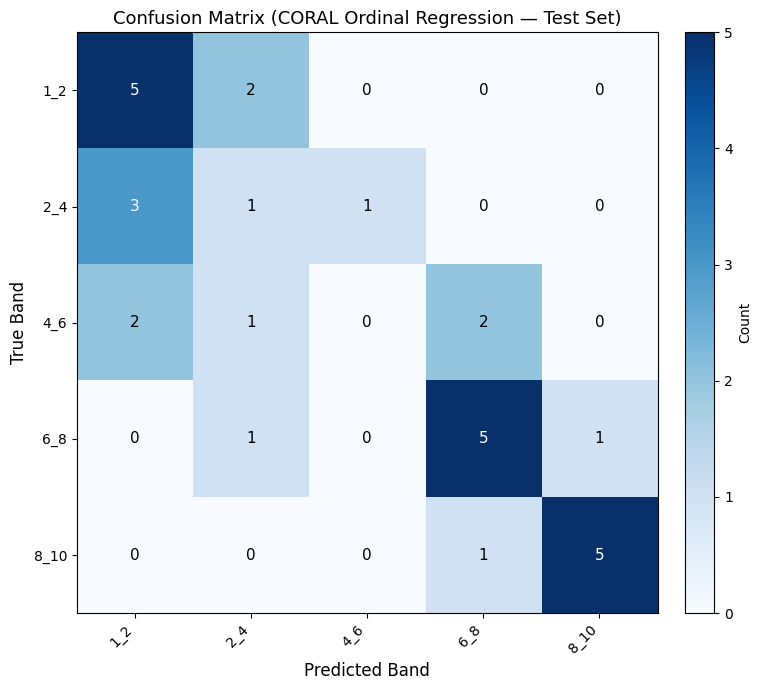


Saved predictions to: D:\DAI_HOC\THI\DATASTORM 2025\DATASTORM---QUAQUYT\results\test_predictions.csv


In [90]:
# --- Test evaluation (CORAL Ordinal Regression) ---
from sklearn.metrics import classification_report, confusion_matrix

# Map rank to band label for reporting
RANK_TO_BAND = {0: "1_2", 1: "2_4", 2: "4_6", 3: "6_8", 4: "8_10"}

model.eval()
all_pred_ranks = []
all_true_ranks = []
all_video_ids = []
all_envs = []
all_band_str = []

with torch.no_grad():
    for Xj, Xg, y_rank, meta, masks in tqdm(test_loader):
        Xj = Xj.to(DEVICE)
        Xg = Xg.to(DEVICE)
        y_rank = y_rank.to(DEVICE)

        logits_ord, logits_cls = model(Xj, Xg)  # (B,4), (B,5)
        
        # Infer rank from ordinal logits using expected value
        pred_rank = infer_rank_from_ordinal(logits_ord)

        all_pred_ranks.extend(pred_rank.cpu().numpy().tolist())
        all_true_ranks.extend(y_rank.cpu().numpy().tolist())

        for m in meta:
            all_video_ids.append(m["video_id"])
            all_envs.append(m["env"])
            all_band_str.append(m["band_str"])

# Convert ranks to band labels for reporting
all_bands = [RANK_TO_BAND[i] for i in range(5)]
true_band_labels = [RANK_TO_BAND[r] for r in all_true_ranks]
pred_band_labels = [RANK_TO_BAND[r] for r in all_pred_ranks]

print("=" * 70)
print("CORAL ORDINAL REGRESSION RESULTS (Test Set)")
print("=" * 70)
print(classification_report(true_band_labels, pred_band_labels, target_names=all_bands, digits=4))

# Compute MAE in rank space
mae_rank = np.mean(np.abs(np.array(all_pred_ranks) - np.array(all_true_ranks)))
print(f"\nMean Absolute Error (Rank Space): {mae_rank:.4f}")

cm = confusion_matrix(
    all_true_ranks,
    all_pred_ranks,
    labels=list(range(5))
)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm, cmap="Blues")

max_val = cm.max()

for i in range(5):
    for j in range(5):
        value = cm[i, j]
        ax.text(
            j, i,
            f"{value}",
            ha="center",
            va="center",
            color="white" if value > max_val * 0.5 else "black",
            fontsize=11
        )

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(all_bands, rotation=45, ha="right")
ax.set_yticklabels(all_bands)

ax.set_xlabel("Predicted Band", fontsize=12)
ax.set_ylabel("True Band", fontsize=12)
ax.set_title("Confusion Matrix (CORAL Ordinal Regression — Test Set)", fontsize=13)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
plt.tight_layout()
plt.show()

# Save predictions with full mapping to metadata
pred_df = pd.DataFrame({
    "video_id": all_video_ids,
    "env": all_envs,
    "true_rank": all_true_ranks,
    "pred_rank": all_pred_ranks,
    "true_band": true_band_labels,
    "pred_band": pred_band_labels,
})
out_csv = OUTPUT_ROOT / "test_predictions.csv"
pred_df.to_csv(out_csv, index=False)
print(f"\nSaved predictions to: {out_csv}")